In [ ]:
!pip install transformers==3.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 3.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 769.0/769.0 kB 18.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 44.7 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)


In [ ]:
!pip list | grep torch


pytorch-ignite                        0.5.2
pytorch-lightning                     2.5.2
torch                                 2.6.0+cu124
torchao                               0.10.0
torchaudio                            2.6.0+cu124
torchdata                             0.11.0
torchinfo                             1.8.0
torchmetrics                          1.7.3
torchsummary                          1.5.1
torchtune                             0.6.1
torchvision                           0.21.0+cu124


In [ ]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


CUDA Available: True
GPU Name: Tesla T4


In [ ]:
!nvidia-smi


Fri Sep 12 12:52:01 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import pandas as pd
from sklearn.utils import resample

# Load the dataset
df = pd.read_csv('/kaggle/input/overall-column-dataset-updated-msc/overall updated upsampled_data.csv')  # Replace with your dataset's file name

# Map scores to labels
def map_scores(score):
    if score in [4, 5]:
        return 2  # Positive
    elif score in [1, 2]:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral

df['Overall_Label'] = df['Overall'].apply(map_scores)  # Replace 'Your_Score_Column' with the actual column name

# Separate the dataset by label
df_0 = df[df['Overall_Label'] == 0]
df_1 = df[df['Overall_Label'] == 1]
df_2 = df[df['Overall_Label'] == 2]

# Perform upsampling
target_size = 3688  # Target size for each label

df_0_upsampled = resample(df_0, replace=True, n_samples=target_size, random_state=42)
df_1_upsampled = resample(df_1, replace=True, n_samples=target_size, random_state=42)
df_2_upsampled = resample(df_2, replace=True, n_samples=target_size, random_state=42)

# Combine the upsampled dataframes
df_balanced = pd.concat([df_0_upsampled, df_1_upsampled, df_2_upsampled])

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the balanced dataset to the working directory
df_balanced.to_csv('balanced_dataset.csv', index=False)

print(f"Balanced dataset saved as 'balanced_dataset.csv' in the working directory.")


Balanced dataset saved as 'balanced_dataset.csv' in the working directory.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import seaborn as sns
import transformers
import json
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import logging
from torch import cuda
from transformers import AutoTokenizer, AutoModel

logging.basicConfig(level=logging.ERROR)

# Select device
device = 'cuda' if cuda.is_available() else 'cpu'


In [ ]:
import pandas as pd

dataset_path = "/kaggle/working/balanced_dataset.csv"


df = pd.read_csv(dataset_path)
df.head()


,Combined,Overall,Overall_Label
0,"Name: Md Fazla Rabbi, Job_Title: Senior Softwa...",4,2
1,"Name: Fatima Tasnim, Job_Title: Software Engin...",4,2
2,"Name: Rajesh Debnath, Job_Title: Software Engi...",5,2
3,"Name: Foysol Ahmed Shuvo, Job_Title: Full stac...",3,1
4,"Name: Majbah Uddin, Job_Title: Software Engine...",5,2


In [ ]:
# Create the labels based on score
def map_labels(score):
    if score == 1 or score == 2:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral
    elif score == 4 or score == 5:
        return 2  # Positive

# Apply the mapping function to the 'Skills' column
df['Overall_Label'] = df['Overall'].apply(map_labels)

print("Mapped Overall_Label:")
print(df['Overall_Label'].value_counts())

print(df.head())

df.to_csv('/kaggle/working/Overall_Label.csv', index=False)


Mapped Overall_Label:
Overall_Label
2    3688
1    3688
0    3688
Name: count, dtype: int64
                                            Combined  Overall  Overall_Label
0  Name: Md Fazla Rabbi, Job_Title: Senior Softwa...        4              2
1  Name: Fatima Tasnim, Job_Title: Software Engin...        4              2
2  Name: Rajesh Debnath, Job_Title: Software Engi...        5              2
3  Name: Foysol Ahmed Shuvo, Job_Title: Full stac...        3              1
4  Name: Majbah Uddin, Job_Title: Software Engine...        5              2


In [ ]:
from transformers import AutoTokenizer
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the tokenizer using AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("Peraboom/LastBERT")

# Load the dataset
df = pd.read_csv("/kaggle/working/Overall_Label.csv")

# Function to tokenize the text using the tokenizer
def tokenize_function(text):
    return tokenizer(
        text,
        padding='max_length',   # pad to max length
        truncation=True,        # truncate if too long
        max_length=256,         # maximum length
        return_tensors='pt'     # return PyTorch tensors
    )

# Apply tokenization to the 'Combined' column
df['tokenized'] = df['Combined'].apply(lambda x: tokenize_function(x))

# Display the first few tokenized outputs and original labels
print(df['tokenized'].head())
print(df[['Combined', 'Overall_Label']].head())


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

0    [input_ids, token_type_ids, attention_mask]
1    [input_ids, token_type_ids, attention_mask]
2    [input_ids, token_type_ids, attention_mask]
3    [input_ids, token_type_ids, attention_mask]
4    [input_ids, token_type_ids, attention_mask]
Name: tokenized, dtype: object
                                            Combined  Overall_Label
0  Name: Md Fazla Rabbi, Job_Title: Senior Softwa...              2
1  Name: Fatima Tasnim, Job_Title: Software Engin...              2
2  Name: Rajesh Debnath, Job_Title: Software Engi...              2
3  Name: Foysol Ahmed Shuvo, Job_Title: Full stac...              1
4  Name: Majbah Uddin, Job_Title: Software Engine...              2


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/working/Overall_Label.csv")  # This is your labeled data file


# Split the data into training (80%), validation (10%), and test (10%) sets
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# Check the shape of the split data
print(f"Training Data Shape: {train_data.shape}")
print(f"Validation Data Shape: {val_data.shape}")
print(f"Test Data Shape: {test_data.shape}")

output_dir = "/kaggle/working/"

train_data.to_csv(f"{output_dir}train_data.csv", index=False)
val_data.to_csv(f"{output_dir}val_data.csv", index=False)
test_data.to_csv(f"{output_dir}test_data.csv", index=False)


print("train_data.csv")
print("val_data.csv")
print("test_data.csv")


Training Data Shape: (8851, 3)
Validation Data Shape: (1106, 3)
Test Data Shape: (1107, 3)
train_data.csv
val_data.csv
test_data.csv


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

# Load LastBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("Peraboom/LastBERT")

# Define the custom PyTorch Dataset
class SkillsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get the combined text and label for a specific index
        text = str(self.data.iloc[idx]['Combined'])
        label = self.data.iloc[idx]['Overall_Label']

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
            return_token_type_ids=True
        )

        # Extract the tensors from the encoding dictionary and squeeze the batch dimension
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        token_type_ids = encoding['token_type_ids'].squeeze(0)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'token_type_ids': token_type_ids,
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
train_dataset = SkillsDataset(train_data, tokenizer)
val_dataset = SkillsDataset(val_data, tokenizer)

# Create dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Check a batch from the train DataLoader
for batch in train_dataloader:
    print(f"Input IDs: {batch['input_ids']}")
    print(f"Attention Mask: {batch['attention_mask']}")
    print(f"Token Type IDs: {batch['token_type_ids']}")
    print(f"Labels: {batch['labels']}")
    break  # Just to check one batch only


Input IDs: tensor([[ 101, 2171, 1024,  ..., 6364, 1006,  102],
        [ 101, 2171, 1024,  ...,    0,    0,    0],
        [ 101, 2171, 1024,  ..., 6364, 1006,  102],
        ...,
        [ 101, 2171, 1024,  ..., 2079, 1996,  102],
        [ 101, 2171, 1024,  ..., 1037, 1087,  102],
        [ 101, 2171, 1024,  ..., 1999, 9610,  102]])
Attention Mask: tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]])
Token Type IDs: tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
Labels: tensor([2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 2, 1, 0, 1, 2])


In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification

# Define the LastBERT-based model
class LastBERTClass(nn.Module):
    def __init__(self, num_labels=3):
        super(LastBERTClass, self).__init__()

        self.lastbert = AutoModelForSequenceClassification.from_pretrained(
            "Peraboom/LastBERT",
            num_labels=num_labels,
            ignore_mismatched_sizes=True  # Fixes classifier size mismatch
        )

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        # Forward pass through LastBERT
        output = self.lastbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        return output.logits

# Initialize the model
model = LastBERTClass(num_labels=3)  # Negative (0), Neutral (1), Positive (2)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

# Print model summary
print(model)


config.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

2025-09-12 12:52:39.926196: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757681560.267722      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757681560.364804      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


model.safetensors:   0%|          | 0.00/119M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Peraboom/LastBERT and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 384]) in the checkpoint and torch.Size([3, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


LastBERTClass(
  (lastbert): BertForSequenceClassification(
    (bert): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 384, padding_idx=0)
        (position_embeddings): Embedding(512, 384)
        (token_type_embeddings): Embedding(2, 384)
        (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-5): 6 x BertLayer(
            (attention): BertAttention(
              (self): BertSdpaSelfAttention(
                (query): Linear(in_features=384, out_features=384, bias=True)
                (key): Linear(in_features=384, out_features=384, bias=True)
                (value): Linear(in_features=384, out_features=384, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=384, out_features=

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, RandomSampler, SequentialSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW  # Correct import
from sklearn.model_selection import train_test_split

# Define the custom Dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = self.texts[item]
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Prepare data
texts = df['Combined'].tolist()
labels = df['Overall_Label'].tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

tokenizer = AutoTokenizer.from_pretrained("Peraboom/LastBERT")

train_dataset = TextDataset(train_texts, train_labels, tokenizer, max_len=256)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, max_len=256)

# Dataloaders
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=8)
val_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=8)

# Define the LastBERT model class
class LastBERTClass(nn.Module):
    def __init__(self, num_labels=3):
        super(LastBERTClass, self).__init__()
        self.lastbert = AutoModelForSequenceClassification.from_pretrained(
            "Peraboom/LastBERT",
            num_labels=num_labels,
            ignore_mismatched_sizes=True
        )

    def forward(self, input_ids, attention_mask):
        output = self.lastbert(input_ids=input_ids, attention_mask=attention_mask)
        return output.logits

# Initialize model
model = LastBERTClass(num_labels=3)

# Multi-GPU support
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=1e-7, weight_decay=0.01)

# Training loop
def train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, epochs=12):
    best_val_loss = float('inf')
    patience = 2
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch in train_dataloader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(logits, dim=1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = running_loss / len(train_dataloader)
        train_accuracy = correct_train / total_train

        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for batch in val_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs

                loss = criterion(logits, labels)
                running_val_loss += loss.item()
                _, predicted = torch.max(logits, dim=1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = running_val_loss / len(val_dataloader)
        val_accuracy = correct_val / total_val

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
        print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

# Train model
train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, epochs=20)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Peraboom/LastBERT and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 384]) in the checkpoint and torch.Size([3, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using 2 GPUs
Epoch 1/20
Training Loss: 1.1024, Training Accuracy: 0.3409
Validation Loss: 1.0965, Validation Accuracy: 0.4415
Epoch 2/20
Training Loss: 1.0960, Training Accuracy: 0.3638
Validation Loss: 1.0919, Validation Accuracy: 0.4690
Epoch 3/20
Training Loss: 1.0913, Training Accuracy: 0.3994
Validation Loss: 1.0878, Validation Accuracy: 0.5183
Epoch 4/20
Training Loss: 1.0876, Training Accuracy: 0.4284
Validation Loss: 1.0833, Validation Accuracy: 0.7094
Epoch 5/20
Training Loss: 1.0832, Training Accuracy: 0.4655
Validation Loss: 1.0780, Validation Accuracy: 0.7045
Epoch 6/20
Training Loss: 1.0777, Training Accuracy: 0.4982
Validation Loss: 1.0715, Validation Accuracy: 0.7131
Epoch 7/20
Training Loss: 1.0709, Training Accuracy: 0.5516
Validation Loss: 1.0633, Validation Accuracy: 0.7388
Epoch 8/20
Training Loss: 1.0619, Training Accuracy: 0.5859
Validation Loss: 1.0530, Validation Accuracy: 0.6954
Epoch 9/20
Training Loss: 1.0510, Training Accuracy: 0.6292
Validation Loss: 1.0392

In [ ]:
# Saving the trained model and tokenizer
def save_model_and_tokenizer(model, tokenizer, model_path='lastbert_model.pth', tokenizer_path='lastbert_tokenizer'):
    # Save the model's state_dict
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


    tokenizer.save_pretrained(tokenizer_path)
    print(f"Tokenizer saved to {tokenizer_path}")


save_model_and_tokenizer(model, tokenizer)

Model saved to lastbert_model.pth
Tokenizer saved to lastbert_tokenizer


In [ ]:
import torch
from sklearn.metrics import classification_report, hamming_loss, roc_auc_score
import numpy as np


def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Store probabilities
            probs = torch.softmax(logits, dim=1)
            all_probs.extend(probs.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Check the number of unique labels in the predicted labels
    unique_labels = np.unique(all_labels)
    print(f"Unique Labels: {unique_labels}")

    # Set the correct number of classes and target names
    num_classes = len(unique_labels)
    target_names = [f"Class {i}" for i in unique_labels]

    # Classification Report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=target_names))

    # Hamming Loss
    hamming = hamming_loss(all_labels, all_preds)
    print(f"Hamming Loss: {hamming:.4f}")


evaluate_model(model, val_dataloader, device)


Unique Labels: [0 1 2]
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.97      1.00      0.98       735
     Class 1       0.90      0.90      0.90       752
     Class 2       0.91      0.88      0.90       726

    accuracy                           0.93      2213
   macro avg       0.93      0.93      0.93      2213
weighted avg       0.93      0.93      0.93      2213

Hamming Loss: 0.0718


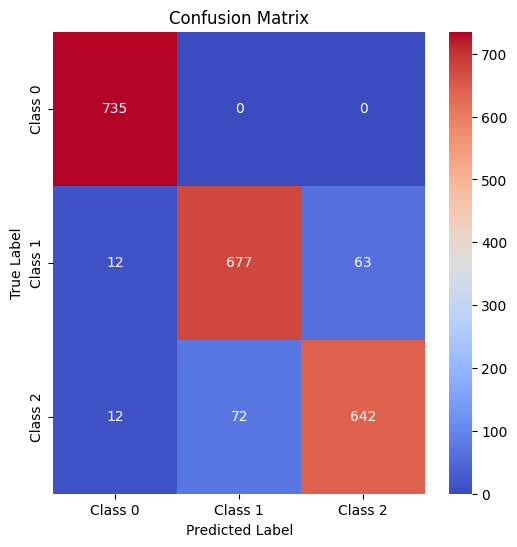

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(cm)

# Plotting Confusion Matrix with different color
def plot_confusion_matrix(cm):
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", cbar=True,
                xticklabels=["Class 0","Class 1", "Class 2"],
                yticklabels=["Class 0","Class 1", "Class 2"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Call the evaluate_model function to evaluate the model
evaluate_model(model, val_dataloader, device)


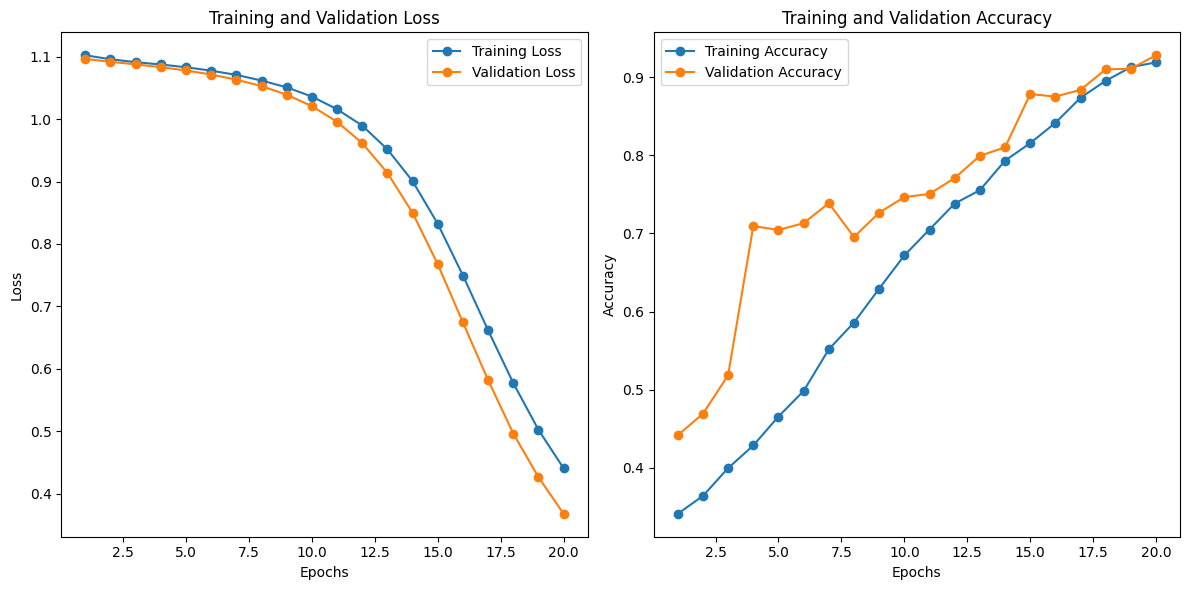

In [ ]:
import matplotlib.pyplot as plt

# Data from the training log
epochs = list(range(1, 21))
training_loss = [1.1024, 1.0960, 1.0913, 1.0876, 1.0832, 1.0777, 1.0709, 1.0619, 1.0510,
              1.0362, 1.0159, 0.9897, 0.9516, 0.9006, 0.8322, 0.7494, 0.6615, 0.5770, 0.5021, 0.4403]
validation_loss = [1.0965, 1.0919, 1.0878, 1.0833, 1.0780, 1.0715, 1.0633, 1.0530, 1.0392,
            1.0208, 0.9958, 0.9616, 0.9138, 0.8498, 0.7674, 0.6741, 0.5818, 0.4961, 0.4262, 0.3675]
training_accuracy = [0.3409, 0.3638, 0.3994, 0.4284, 0.4655, 0.4982, 0.5516, 0.5859, 0.6292,
             0.6718, 0.7050, 0.7382, 0.7554, 0.7932, 0.8156, 0.8416, 0.8738, 0.8955, 0.9130, 0.9191]

validation_accuracy = [0.4415, 0.4690, 0.5183, 0.7094, 0.7045, 0.7131, 0.7388, 0.6954, 0.7266,
           0.7465, 0.7506, 0.7709, 0.7994, 0.8102, 0.8784, 0.8753, 0.8839, 0.9101, 0.9110, 0.9282]


# Plotting the training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, training_loss, label="Training Loss", marker='o')
plt.plot(epochs, validation_loss, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(False)

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, training_accuracy, label="Training Accuracy", marker='o')
plt.plot(epochs, validation_accuracy, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()


In [ ]:
def generate_predictions_and_scores(model, dataloader, device):
    model.eval()
    predicted_scores = []
    actual_scores = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Append logits (predicted scores) and actual labels
            predicted_scores.extend(logits.cpu().numpy())
            actual_scores.extend(labels.cpu().numpy())

    # Print the results
    print("Predicted Scores (Logits) and Actual Scores (Labels):")
    for pred, actual in zip(predicted_scores, actual_scores):
        print(f"Predicted: {pred}, Actual: {actual}")

    return predicted_scores, actual_scores


# Generate predictions and human scores
predicted_scores, actual_scores = generate_predictions_and_scores(model, val_dataloader, device)


Predicted Scores (Logits) and Actual Scores (Labels):
Predicted: [-0.7462718   1.3062432  -0.58197606], Actual: 1
Predicted: [ 1.9621594 -0.6291232 -1.306071 ], Actual: 0
Predicted: [-0.89031047  1.2854552  -0.44811833], Actual: 1
Predicted: [-0.87044984  1.3501552  -0.5085586 ], Actual: 1
Predicted: [ 1.4777462  -0.19773449 -1.3501555 ], Actual: 0
Predicted: [-1.8255678  -0.09480377  1.6434016 ], Actual: 2
Predicted: [-1.4840415  -0.40800112  1.621129  ], Actual: 2
Predicted: [ 1.7048761 -0.4359144 -1.2789998], Actual: 0
Predicted: [-1.4840415  -0.40800112  1.621129  ], Actual: 2
Predicted: [-1.9510325   0.26409388  1.5096152 ], Actual: 2
Predicted: [-1.004234   0.6867323  0.1469216], Actual: 2
Predicted: [-1.9510325   0.26409388  1.5096152 ], Actual: 2
Predicted: [-0.7847823  1.0020754 -0.3281831], Actual: 1
Predicted: [-1.163719    0.7826697   0.23836102], Actual: 1
Predicted: [-0.53220606  0.7679211  -0.32776132], Actual: 1
Predicted: [-1.7166468  -0.26013654  1.7003138 ], Actual: 

In [ ]:
def map_label_to_score(label):
    """
    Map the predicted labels back to scores.
    0 -> 1.5 (Negative, representing scores 1 and 2)
    1 -> 3.0 (Neutral, representing score 3)
    2 -> 4.5 (Positive, representing scores 4 and 5)
    """
    score_mapping = {0: 1.5, 1: 3.0, 2: 4.5}
    return score_mapping[label]

def generate_predictions_and_scores(model, dataloader, device):
    model.eval()
    predicted_scores = []
    actual_scores = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Get predicted labels (0, 1, 2)
            _, predicted_labels = torch.max(logits, dim=1)

            # Map labels to scores (1.5, 3.0, 4.5)
            predicted_scores.extend([map_label_to_score(label.item()) for label in predicted_labels])
            actual_scores.extend([map_label_to_score(label.item()) for label in labels])

    # Print the results
    print("Predicted Scores and Actual Scores:")
    for pred, actual in zip(predicted_scores, actual_scores):
        print(f"Predicted: {pred:.2f}, Actual: {actual:.2f}")

    return predicted_scores, actual_scores


# Generate predictions and actual scores
predicted_scores, actual_scores = generate_predictions_and_scores(model, val_dataloader, device)


Predicted Scores and Actual Scores:
Predicted: 3.00, Actual: 3.00
Predicted: 1.50, Actual: 1.50
Predicted: 3.00, Actual: 3.00
Predicted: 3.00, Actual: 3.00
Predicted: 1.50, Actual: 1.50
Predicted: 4.50, Actual: 4.50
Predicted: 4.50, Actual: 4.50
Predicted: 1.50, Actual: 1.50
Predicted: 4.50, Actual: 4.50
Predicted: 4.50, Actual: 4.50
Predicted: 3.00, Actual: 4.50
Predicted: 4.50, Actual: 4.50
Predicted: 3.00, Actual: 3.00
Predicted: 3.00, Actual: 3.00
Predicted: 3.00, Actual: 3.00
Predicted: 4.50, Actual: 4.50
Predicted: 1.50, Actual: 1.50
Predicted: 1.50, Actual: 1.50
Predicted: 1.50, Actual: 1.50
Predicted: 1.50, Actual: 1.50
Predicted: 1.50, Actual: 1.50
Predicted: 1.50, Actual: 1.50
Predicted: 3.00, Actual: 3.00
Predicted: 4.50, Actual: 4.50
Predicted: 3.00, Actual: 3.00
Predicted: 1.50, Actual: 4.50
Predicted: 3.00, Actual: 3.00
Predicted: 3.00, Actual: 3.00
Predicted: 4.50, Actual: 4.50
Predicted: 1.50, Actual: 1.50
Predicted: 1.50, Actual: 1.50
Predicted: 4.50, Actual: 3.00
Pred

In [ ]:
def generate_predictions_and_scores_with_mismatches(model, dataloader, device):
    model.eval()
    predicted_scores = []
    actual_scores = []
    mismatches = []  # To store mismatched predictions

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Get predicted labels (0, 1, 2)
            _, predicted_labels = torch.max(logits, dim=1)

            # Map labels to scores (1.5, 3.0, 4.5)
            predicted_batch_scores = [map_label_to_score(label.item()) for label in predicted_labels]
            actual_batch_scores = [map_label_to_score(label.item()) for label in labels]

            predicted_scores.extend(predicted_batch_scores)
            actual_scores.extend(actual_batch_scores)

            # Check for mismatches and record them
            for pred, actual in zip(predicted_batch_scores, actual_batch_scores):
                if pred != actual:
                    mismatches.append((pred, actual))

    # Print all predictions
    print("Predicted Scores and Actual Scores:")
    for pred, actual in zip(predicted_scores, actual_scores):
        print(f"Predicted: {pred:.2f}, Actual: {actual:.2f}")

    # Print mismatched predictions
    print("\nMismatched Predictions (Predicted != Actual):")
    for pred, actual in mismatches:
        print(f"Predicted: {pred:.2f}, Actual: {actual:.2f}")

    return predicted_scores, actual_scores, mismatches


# Generate predictions, actual scores, and mismatches
predicted_scores, actual_scores, mismatches = generate_predictions_and_scores_with_mismatches(model, val_dataloader, device)


Predicted Scores and Actual Scores:
Predicted: 3.00, Actual: 3.00
Predicted: 1.50, Actual: 1.50
Predicted: 3.00, Actual: 3.00
Predicted: 3.00, Actual: 3.00
Predicted: 1.50, Actual: 1.50
Predicted: 4.50, Actual: 4.50
Predicted: 4.50, Actual: 4.50
Predicted: 1.50, Actual: 1.50
Predicted: 4.50, Actual: 4.50
Predicted: 4.50, Actual: 4.50
Predicted: 3.00, Actual: 4.50
Predicted: 4.50, Actual: 4.50
Predicted: 3.00, Actual: 3.00
Predicted: 3.00, Actual: 3.00
Predicted: 3.00, Actual: 3.00
Predicted: 4.50, Actual: 4.50
Predicted: 1.50, Actual: 1.50
Predicted: 1.50, Actual: 1.50
Predicted: 1.50, Actual: 1.50
Predicted: 1.50, Actual: 1.50
Predicted: 1.50, Actual: 1.50
Predicted: 1.50, Actual: 1.50
Predicted: 3.00, Actual: 3.00
Predicted: 4.50, Actual: 4.50
Predicted: 3.00, Actual: 3.00
Predicted: 1.50, Actual: 4.50
Predicted: 3.00, Actual: 3.00
Predicted: 3.00, Actual: 3.00
Predicted: 4.50, Actual: 4.50
Predicted: 1.50, Actual: 1.50
Predicted: 1.50, Actual: 1.50
Predicted: 4.50, Actual: 3.00
Pred